In [35]:
from pathlib import Path
import shutil
import re
import random

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt

In [11]:
IMAGES_DIR = Path("lines flattened")
CSV_FILE = Path("sentences.csv")

AUG_IMAGES_DIR = Path("lines flattened augmented")
AUG_CSV_FILE = Path("sentences_augmented.csv")

In [13]:
if AUG_IMAGES_DIR.exists():
    shutil.rmtree(AUG_IMAGES_DIR)

AUG_IMAGES_DIR.mkdir()

In [15]:
df = pd.read_csv(CSV_FILE)

df = df[["id", "sentence"]].copy()

print(df.head())
print(df.shape)

            id                               sentence
0  a01-000u-00      A MOVE to stop Mr. Gaitskell from
1  a01-000u-01  nominating any more Labour life Peers
2  a01-000u-02   is to be made at a meeting of Labour
3  a01-000u-03      Ps tomorrow. Mr. Michael Foot has
4  a01-000u-04   put down a resolution on the subject
(13353, 2)


In [17]:
df["image_path"] = df["id"].apply(lambda x: IMAGES_DIR / f"{x}.png")

missing = df[~df["image_path"].apply(lambda x: x.exists())]

print("Number of rows in CSV:", len(df))
print("Missing images:", len(missing))

if len(missing) > 0:
    display(missing.head())

df.head()

Number of rows in CSV: 13353
Missing images: 0


,id,sentence,image_path
0,a01-000u-00,A MOVE to stop Mr. Gaitskell from,lines flattened\a01-000u-00.png
1,a01-000u-01,nominating any more Labour life Peers,lines flattened\a01-000u-01.png
2,a01-000u-02,is to be made at a meeting of Labour,lines flattened\a01-000u-02.png
3,a01-000u-03,Ps tomorrow. Mr. Michael Foot has,lines flattened\a01-000u-03.png
4,a01-000u-04,put down a resolution on the subject,lines flattened\a01-000u-04.png


In [19]:
# define the helper function to add newly created images

def add_augmented_image(df_aug, original_row, augmented_image, augmentation_name):
    original_id = original_row["id"]

    new_filename = f"{original_id}__{augmentation_name}.png"
    new_path = AUG_IMAGES_DIR / new_filename

    save_image(new_path, augmented_image)

    new_row = {
        "id": new_filename,
        "sentence": original_row["sentence"],
        "original_id": original_id,
        "augmentation": augmentation_name
    }

    df_aug = pd.concat(
        [df_aug, pd.DataFrame([new_row])],
        ignore_index=True
    )

    df_aug.to_csv(AUG_CSV_FILE, index=False)

    return df_aug

In [21]:
# add container for filenames already used for dataset augmentation 

used_ids = set()

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

Total images: 13353
Already used: 0
Available: 13353


In [23]:
# define read and save helpers

def read_image(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    return image


def save_image(image_path, image):
    ok = cv2.imwrite(str(image_path), image)

    if not ok:
        raise ValueError(f"Could not save image: {image_path}")

In [25]:
# define new df with both original and augmeneted image paths + text

rows = []

for _, row in df.iterrows():
    old_path = row["image_path"]
    new_filename = f"{row['id']}.png"
    new_path = AUG_IMAGES_DIR / new_filename

    shutil.copy2(old_path, new_path)

    rows.append({
        "id": new_filename,
        "sentence": row["sentence"],
        "original_id": row["id"],
        "augmentation": "original"
    })

df_aug = pd.DataFrame(rows)

df_aug.to_csv(AUG_CSV_FILE, index=False)

print(df_aug.head())
print(df_aug.shape)
print(df_aug["augmentation"].value_counts())

                id                               sentence  original_id  \
0  a01-000u-00.png      A MOVE to stop Mr. Gaitskell from  a01-000u-00   
1  a01-000u-01.png  nominating any more Labour life Peers  a01-000u-01   
2  a01-000u-02.png   is to be made at a meeting of Labour  a01-000u-02   
3  a01-000u-03.png      Ps tomorrow. Mr. Michael Foot has  a01-000u-03   
4  a01-000u-04.png   put down a resolution on the subject  a01-000u-04   

  augmentation  
0     original  
1     original  
2     original  
3     original  
4     original  
(13353, 4)
augmentation
original    13353
Name: count, dtype: int64


In [27]:
# randomly select 100 images for Gaussian noise augmentation

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

gaussian_sample = available_df.sample(n=n_images, random_state=42).copy()

print("Selected for Gaussian noise:", len(gaussian_sample))
gaussian_sample.head()

Total images: 13353
Already used: 0
Available: 13353
Selected for Gaussian noise: 100


,id,sentence,image_path
1783,a06-114-07,On the eve of August Bank Holiday,lines flattened\a06-114-07.png
7591,g06-042g-02,"early as 1830, when Anglesey believed himself ...",lines flattened\g06-042g-02.png
10870,m01-115-00,"""Now, to summarize what I think our",lines flattened\m01-115-00.png
1978,b01-073-10,not weaken it further by desertion.,lines flattened\b01-073-10.png
1085,a03-071-03,"it has so far, that such a project would",lines flattened\a03-071-03.png


In [29]:
# Gaussian noise function

def add_gaussian_noise(image, mean=0, std=12):
    image = image.astype(np.float32)

    noise = np.random.normal(
        loc=mean,
        scale=std,
        size=image.shape
    )

    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

    return noisy_image

In [59]:
# add noise and update dataset

before_after_gaussian = []

np.random.seed(42)

for _, row in gaussian_sample.iterrows():
    original_image = read_image(row["image_path"])

    noisy_image = add_gaussian_noise(
        original_image,
        mean=0,
        std=40
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=noisy_image,
        augmentation_name="gaussian_noise"
    )

    before_after_gaussian.append({
        "id": row["id"],
        "before": original_image,
        "after": noisy_image
    })

used_ids.update(gaussian_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Gaussian noise done.")
print("Current augmented dataframe shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Gaussian noise done.
Current augmented dataframe shape: (13453, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
Name: count, dtype: int64

Used IDs: 100


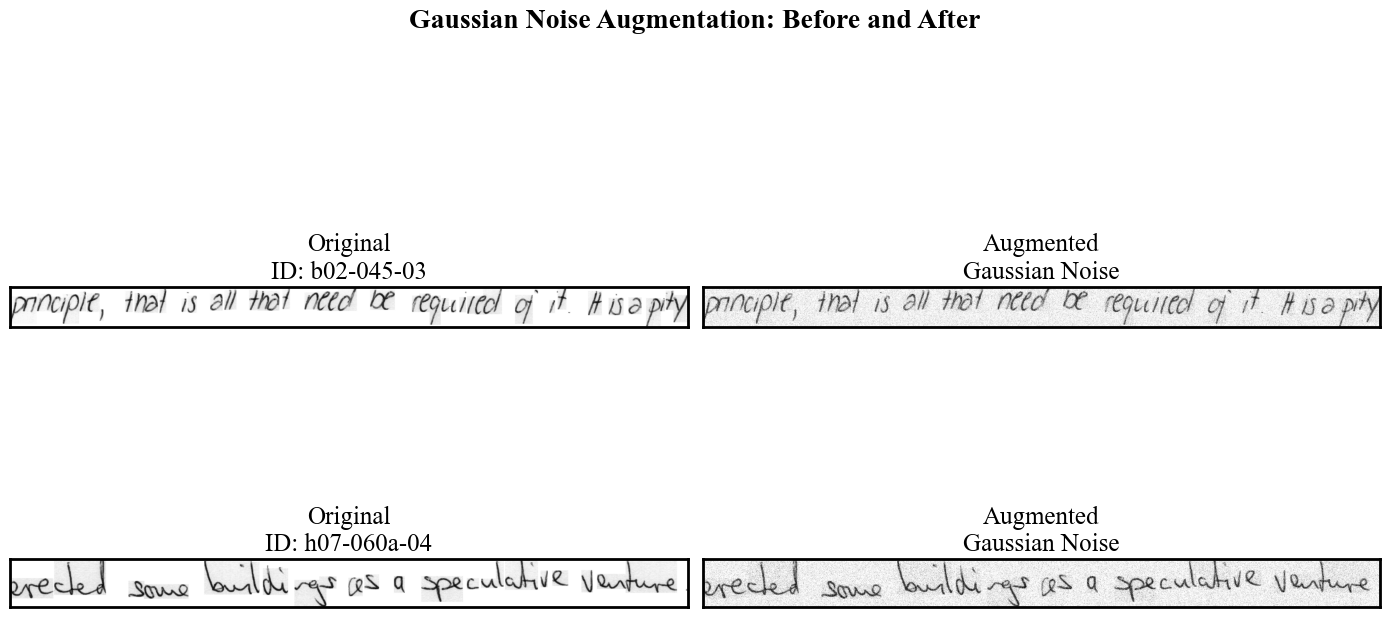

In [61]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20

FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_gaussian, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Gaussian Noise Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    # Original
    axes[i, 0].imshow(ex["before"], cmap="gray")
    axes[i, 0].set_title(
        f"Original\nID: {ex['id']}",
        fontsize=TITLE_SIZE,
        fontname=FONT_FAMILY
    )
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    for spine in axes[i, 0].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

    # Augmented
    axes[i, 1].imshow(ex["after"], cmap="gray")
    axes[i, 1].set_title(
        "Augmented\nGaussian Noise",
        fontsize=TITLE_SIZE,
        fontname=FONT_FAMILY
    )
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])
    for spine in axes[i, 1].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

plt.tight_layout()
plt.savefig("Gaussian noise.png", dpi = 400)
plt.show()

In [63]:
# check whether the noise was applied in the correct way. mean absolute difference around 5-15

ex = before_after_gaussian[0]

before = ex["before"]
after = ex["after"]

difference = after.astype(np.int16) - before.astype(np.int16)

print("Mean absolute difference:", np.mean(np.abs(difference)))
print("Max difference:", np.max(np.abs(difference)))
print("Before min/max:", before.min(), before.max())
print("After min/max:", after.min(), after.max())

Mean absolute difference: 18.46948851272709
Max difference: 179
Before min/max: 26 255
After min/max: 0 255


In [85]:
# get images for text rotation
available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

rotation_sample = available_df.sample(n=n_images, random_state=43).copy()

print("Selected for rotation:", len(rotation_sample))
rotation_sample.head()

Total images: 13353
Already used: 100
Available: 13253
Selected for rotation: 100


,id,sentence,image_path
6641,g04-022-04,incumbency I was asked if I would start,lines flattened\g04-022-04.png
3016,c03-000c-04,"author with Miss Delaney of the script, and",lines flattened\c03-000c-04.png
11053,m02-102-04,were now being bought forward in their,lines flattened\m02-102-04.png
10103,k07-146-07,have asked him to join us. I 'm so,lines flattened\k07-146-07.png
11227,m04-072-02,"two-twenty carried, for him, a cargo more",lines flattened\m04-072-02.png


In [77]:
# define the function for text rotation
# finds text and rotates text onyl, puts it back on canvas

def rotate_text_only_expand_canvas(image, angle, padding=12, canvas_padding=25):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    ch, cw = text_crop.shape
    center = (cw / 2, ch / 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    cos = abs(rotation_matrix[0, 0])
    sin = abs(rotation_matrix[0, 1])

    rotated_w = int((ch * sin) + (cw * cos))
    rotated_h = int((ch * cos) + (cw * sin))

    rotation_matrix[0, 2] += (rotated_w / 2) - center[0]
    rotation_matrix[1, 2] += (rotated_h / 2) - center[1]

    rotated_crop = cv2.warpAffine(
        text_crop,
        rotation_matrix,
        (rotated_w, rotated_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255
    )

    new_h = max(h, rotated_h + 2 * canvas_padding)
    new_w = max(w, rotated_w + 2 * canvas_padding)

    output = np.full((new_h, new_w), 255, dtype=np.uint8)

    paste_y = (new_h - rotated_h) // 2
    paste_x = (new_w - rotated_w) // 2

    output[paste_y:paste_y + rotated_h, paste_x:paste_x + rotated_w] = rotated_crop

    return output

In [87]:
# apply rotation, expand the dataset

before_after_rotation = []

np.random.seed(43)

for _, row in rotation_sample.iterrows():
    original_image = read_image(row["image_path"])

    angle = np.random.uniform(-10, 10)

    rotated_image = rotate_text_only_expand_canvas(
        image=original_image,
        angle=angle,
        padding=12,
        canvas_padding=30
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=rotated_image,
        augmentation_name="rotation"
    )

    before_after_rotation.append({
        "id": row["id"],
        "angle": angle,
        "before": original_image,
        "after": rotated_image
    })

used_ids.update(rotation_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Rotation augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Rotation augmentation done.
Current df_aug shape: (13553, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
Name: count, dtype: int64

Used IDs: 200


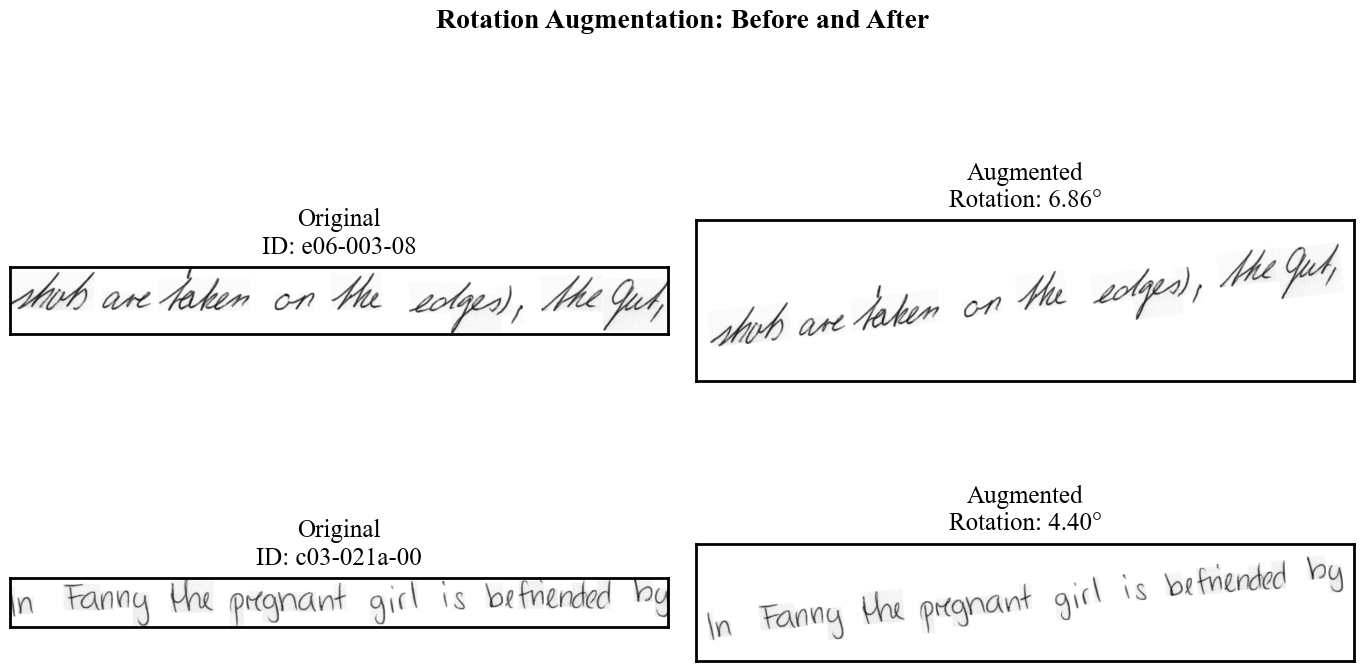

In [89]:
# plot

TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_rotation, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Rotation Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (axes[i, 1], ex["after"], f"Augmented\nRotation: {ex['angle']:.2f}°")
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(
            title,
            fontsize=TITLE_SIZE,
            fontname=FONT_FAMILY,
            pad=10
        )
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("text rotation.png", dpi = 300)
plt.show()

In [103]:
# select images for compression

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

compression_sample = available_df.sample(n=n_images, random_state=44).copy()

print("Selected for compression:", len(compression_sample))
compression_sample.head()

Total images: 13353
Already used: 200
Available: 13153
Selected for compression: 100


,id,sentence,image_path
8413,h01-004-05,in the specialised enquiry for the Royal Commi...,lines flattened\h01-004-05.png
5522,f01-075-03,thought to combine together to form compound,lines flattened\f01-075-03.png
8476,h01-030-08,given to possibilities of reducing,lines flattened\h01-030-08.png
10685,l07-138-01,fish and the gentle putter of the engine,lines flattened\l07-138-01.png
13089,r03-110-05,and write them later. I 've got a bit owing too.,lines flattened\r03-110-05.png


In [101]:
# detext text, comprees it and cut canvas

def compress_text_only_crop_canvas(image, x_scale=0.85, padding=10, outer_padding=6):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    crop_h, crop_w = text_crop.shape

    new_w = max(1, int(crop_w * x_scale))

    compressed_crop = cv2.resize(
        text_crop,
        (new_w, crop_h),
        interpolation=cv2.INTER_AREA
    )

    output_h = crop_h + 2 * outer_padding
    output_w = new_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + crop_h,
        outer_padding:outer_padding + new_w
    ] = compressed_crop

    return output

In [105]:
before_after_compression = []

np.random.seed(44)

for _, row in compression_sample.iterrows():
    original_image = read_image(row["image_path"])

    x_scale = np.random.uniform(0.5, 0.8)

    compressed_image = compress_text_only_crop_canvas(
        image=original_image,
        x_scale=x_scale,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=compressed_image,
        augmentation_name="compression"
    )

    before_after_compression.append({
        "id": row["id"],
        "x_scale": x_scale,
        "before": original_image,
        "after": compressed_image
    })

used_ids.update(compression_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Compression augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Compression augmentation done.
Current df_aug shape: (13653, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
Name: count, dtype: int64

Used IDs: 300


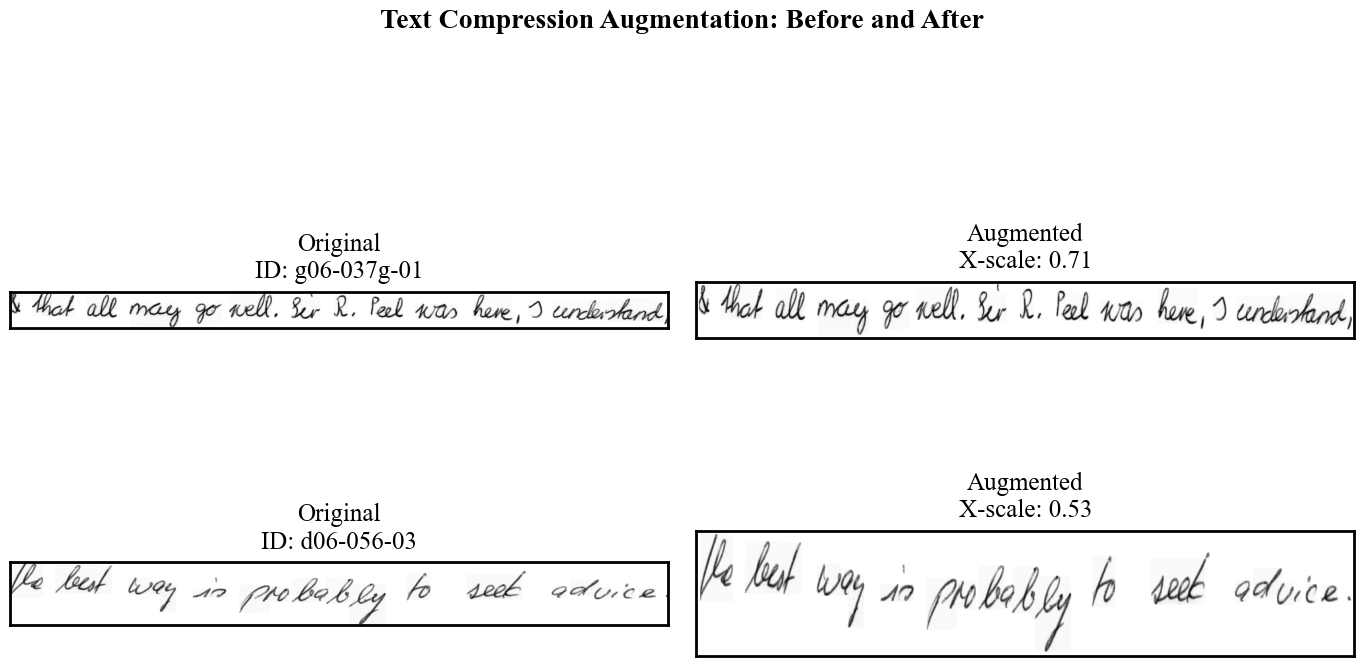

In [121]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_compression, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Text Compression Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (axes[i, 1], ex["after"], f"Augmented\nX-scale: {ex['x_scale']:.2f}")
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=TITLE_SIZE, fontname=FONT_FAMILY, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("compression.png", dpi = 300)
plt.show()

In [123]:
# select images for blurring

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

blur_sample = available_df.sample(n=n_images, random_state=45).copy()

print("Selected for blur:", len(blur_sample))
blur_sample.head()

Total images: 13353
Already used: 300
Available: 13053
Selected for blur: 100


,id,sentence,image_path
8373,g07-077a-06,had been deemed necessary all the,lines flattened\g07-077a-06.png
1615,a05-125-04,for more than 200 yards outside,lines flattened\a05-125-04.png
733,a02-042-07,Accra ?,lines flattened\a02-042-07.png
12681,p03-163-02,didn't ! I was joking. You know I was,lines flattened\p03-163-02.png
10860,m01-110-02,they will promptly give us their hypnotic,lines flattened\m01-110-02.png


In [125]:
# fucntion to detect text, blur and put onto white canvas

def blur_text_only_crop_canvas(image, kernel_size=5, sigma=1.2, padding=10, outer_padding=6):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    blurred_crop = cv2.GaussianBlur(
        text_crop,
        (kernel_size, kernel_size),
        sigmaX=sigma
    )

    crop_h, crop_w = blurred_crop.shape

    output_h = crop_h + 2 * outer_padding
    output_w = crop_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + crop_h,
        outer_padding:outer_padding + crop_w
    ] = blurred_crop

    return output

In [139]:
# apply blur

before_after_blur = []

np.random.seed(45)

for _, row in blur_sample.iterrows():
    original_image = read_image(row["image_path"])

    kernel_size = int(np.random.choice([7, 11]))
    sigma = np.random.uniform(2, 4)

    blurred_image = blur_text_only_crop_canvas(
        image=original_image,
        kernel_size=kernel_size,
        sigma=sigma,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=blurred_image,
        augmentation_name="blur"
    )

    before_after_blur.append({
        "id": row["id"],
        "kernel_size": kernel_size,
        "sigma": sigma,
        "before": original_image,
        "after": blurred_image
    })

used_ids.update(blur_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Blur augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Blur augmentation done.
Current df_aug shape: (13753, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
Name: count, dtype: int64

Used IDs: 400


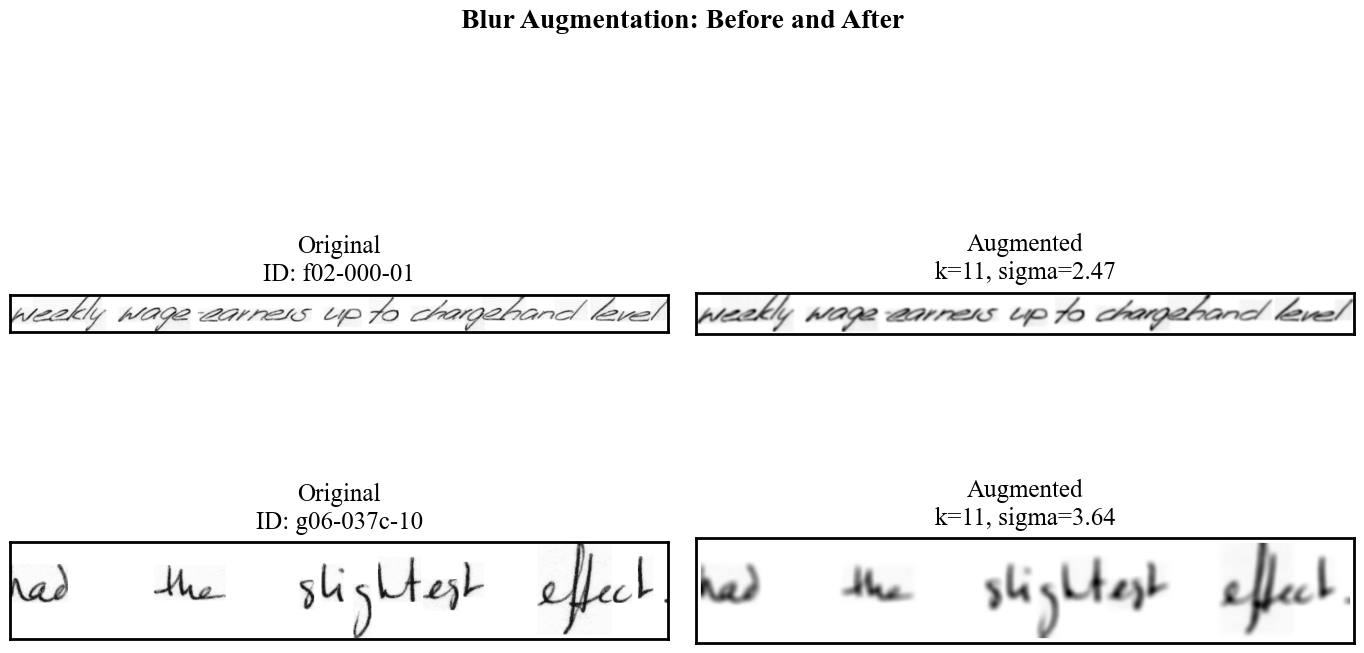

In [152]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_blur, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Blur Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (axes[i, 1], ex["after"], f"Augmented\nk={ex['kernel_size']}, sigma={ex['sigma']:.2f}")
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(
            title,
            fontsize=TITLE_SIZE,
            fontname=FONT_FAMILY,
            pad=10
        )
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("blur.png", dpi = 300)
plt.show()

In [164]:
# select sample for Afine transformations

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

affine_sample = available_df.sample(n=n_images, random_state=46).copy()

print("Selected for affine transformation:", len(affine_sample))
affine_sample.head()

Total images: 13353
Already used: 400
Available: 12953
Selected for affine transformation: 100


,id,sentence,image_path
1296,a04-085-06,the views of a wide section of the,lines flattened\a04-085-06.png
6975,g06-011o-07,a priest : here the priest is 1superceded,lines flattened\g06-011o-07.png
12595,p03-072-07,handsome at other times.,lines flattened\p03-072-07.png
387,a01-063x-09,this is money due to America anyway.,lines flattened\a01-063x-09.png
9558,j06-056-04,"Rose, have proposed that light",lines flattened\j06-056-04.png


In [166]:
# fucntion for affine transformations, still only on text

def affine_text_only_crop_canvas(
    image,
    shear_x=0.18,
    scale_x=1.00,
    scale_y=1.00,
    padding=10,
    outer_padding=8
):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    crop_h, crop_w = text_crop.shape

    M = np.array([
        [scale_x, shear_x, 0],
        [0,       scale_y, 0]
    ], dtype=np.float32)

    corners = np.array([
        [0, 0],
        [crop_w, 0],
        [0, crop_h],
        [crop_w, crop_h]
    ], dtype=np.float32)

    transformed_corners = cv2.transform(
        np.array([corners]),
        M
    )[0]

    min_x = transformed_corners[:, 0].min()
    min_y = transformed_corners[:, 1].min()
    max_x = transformed_corners[:, 0].max()
    max_y = transformed_corners[:, 1].max()

    new_w = int(np.ceil(max_x - min_x)) + 2 * outer_padding
    new_h = int(np.ceil(max_y - min_y)) + 2 * outer_padding

    M[0, 2] = -min_x + outer_padding
    M[1, 2] = -min_y + outer_padding

    transformed = cv2.warpAffine(
        text_crop,
        M,
        (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255
    )

    return transformed

In [168]:
# apply and update

before_after_affine = []

np.random.seed(46)

for _, row in affine_sample.iterrows():
    original_image = read_image(row["image_path"])

    shear_direction = np.random.choice([-1, 1])
    shear_x = shear_direction * np.random.uniform(0.7, 0.9)

    scale_x = np.random.uniform(0.95, 1.10)
    scale_y = np.random.uniform(0.95, 1.15)

    affine_image = affine_text_only_crop_canvas(
        image=original_image,
        shear_x=shear_x,
        scale_x=scale_x,
        scale_y=scale_y,
        padding=10,
        outer_padding=8
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=affine_image,
        augmentation_name="affine"
    )

    before_after_affine.append({
        "id": row["id"],
        "shear_x": shear_x,
        "scale_x": scale_x,
        "scale_y": scale_y,
        "before": original_image,
        "after": affine_image
    })

used_ids.update(affine_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Affine transformation augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Affine transformation augmentation done.
Current df_aug shape: (13853, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
Name: count, dtype: int64

Used IDs: 500


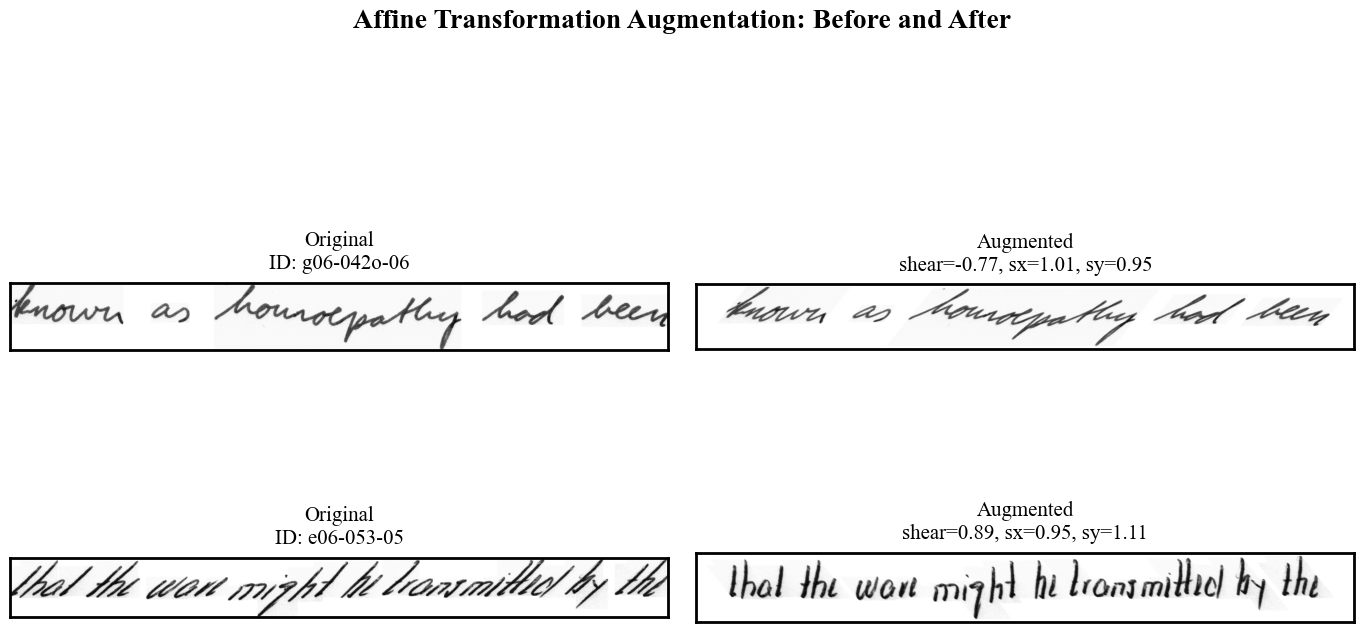

In [172]:
TITLE_SIZE = 15
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_affine, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Affine Transformation Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (
            axes[i, 1],
            ex["after"],
            f"Augmented\nshear={ex['shear_x']:.2f}, sx={ex['scale_x']:.2f}, sy={ex['scale_y']:.2f}"
        )
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=TITLE_SIZE, fontname=FONT_FAMILY, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("affine.png", dpi = 300)
plt.show()

In [174]:
# select text for erosion

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

erosion_sample = available_df.sample(n=n_images, random_state=47).copy()

print("Selected for erosion:", len(erosion_sample))
erosion_sample.head()

Total images: 13353
Already used: 500
Available: 12853
Selected for erosion: 100


,id,sentence,image_path
7780,g06-045p-03,"extraordinary success in France and Italy, and...",lines flattened\g06-045p-03.png
12794,p06-096-02,origin of her recent illness. His notes,lines flattened\p06-096-02.png
4266,d04-089-00,"(1) Matzos is deficient bread, (LECHEM ANJO in...",lines flattened\d04-089-00.png
1060,a03-059-09,"provinces. However, be this election",lines flattened\a03-059-09.png
1611,a05-125-00,A POLITICAL CORRESPONDENT writes : Ban-the-,lines flattened\a05-125-00.png


In [176]:
# texts erosion only

def erode_text_only_crop_canvas(
    image,
    kernel_size=2,
    iterations=1,
    padding=10,
    outer_padding=6
):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    inverted = 255 - text_crop

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (kernel_size, kernel_size)
    )

    eroded_inverted = cv2.erode(
        inverted,
        kernel,
        iterations=iterations
    )

    eroded_crop = 255 - eroded_inverted

    crop_h, crop_w = eroded_crop.shape

    output_h = crop_h + 2 * outer_padding
    output_w = crop_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + crop_h,
        outer_padding:outer_padding + crop_w
    ] = eroded_crop

    return output

In [178]:
before_after_erosion = []

np.random.seed(47)

for _, row in erosion_sample.iterrows():
    original_image = read_image(row["image_path"])

    kernel_size = int(np.random.choice([4, 5]))
    iterations = 1

    eroded_image = erode_text_only_crop_canvas(
        image=original_image,
        kernel_size=kernel_size,
        iterations=iterations,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=eroded_image,
        augmentation_name="erosion"
    )

    before_after_erosion.append({
        "id": row["id"],
        "kernel_size": kernel_size,
        "iterations": iterations,
        "before": original_image,
        "after": eroded_image
    })

used_ids.update(erosion_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Erosion augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Erosion augmentation done.
Current df_aug shape: (13953, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
Name: count, dtype: int64

Used IDs: 600


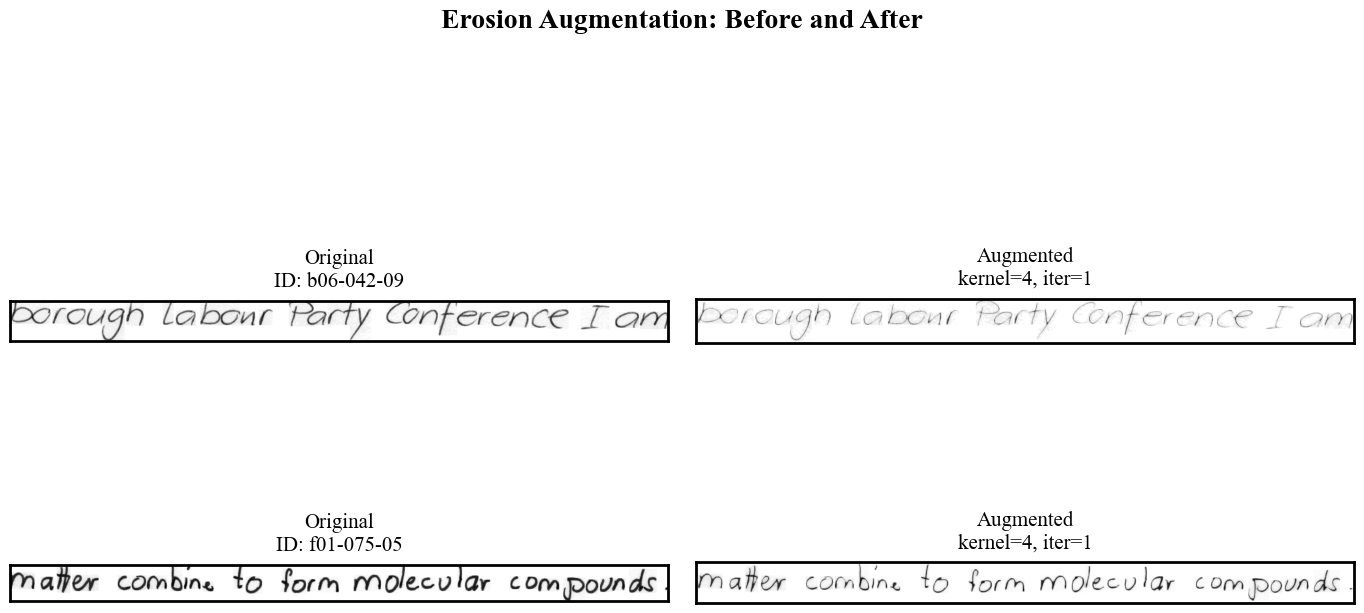

In [182]:
TITLE_SIZE = 15
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_erosion, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Erosion Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (
            axes[i, 1],
            ex["after"],
            f"Augmented\nkernel={ex['kernel_size']}, iter={ex['iterations']}"
        )
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=TITLE_SIZE, fontname=FONT_FAMILY, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("erosion.png", dpi = 300)
plt.show()

In [184]:
# select images for dilation

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

dilation_sample = available_df.sample(n=n_images, random_state=48).copy()

print("Selected for dilation:", len(dilation_sample))
dilation_sample.head()

Total images: 13353
Already used: 600
Available: 12753
Selected for dilation: 100


,id,sentence,image_path
8093,g06-101-05,suggested that the patient should be taken to ...,lines flattened\g06-101-05.png
3987,c06-138-02,points up not only the horror,lines flattened\c06-138-02.png
12579,p03-057-08,"""No,""Di said immediately.""It isn't at",lines flattened\p03-057-08.png
4967,e04-011-01,pinned into place. A similar piece of 1 in.,lines flattened\e04-011-01.png
1388,a05-017-02,He is confident the aim can be achieved.,lines flattened\a05-017-02.png


In [186]:
# dilation function 

def dilate_text_only_crop_canvas(
    image,
    kernel_size=2,
    iterations=1,
    padding=10,
    outer_padding=6
):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    inverted = 255 - text_crop

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (kernel_size, kernel_size)
    )

    dilated_inverted = cv2.dilate(
        inverted,
        kernel,
        iterations=iterations
    )

    dilated_crop = 255 - dilated_inverted

    crop_h, crop_w = dilated_crop.shape

    output_h = crop_h + 2 * outer_padding
    output_w = crop_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + crop_h,
        outer_padding:outer_padding + crop_w
    ] = dilated_crop

    return output

In [188]:
before_after_dilation = []

np.random.seed(48)

for _, row in dilation_sample.iterrows():
    original_image = read_image(row["image_path"])

    kernel_size = int(np.random.choice([4, 5]))
    iterations = 1

    dilated_image = dilate_text_only_crop_canvas(
        image=original_image,
        kernel_size=kernel_size,
        iterations=iterations,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=dilated_image,
        augmentation_name="dilation"
    )

    before_after_dilation.append({
        "id": row["id"],
        "kernel_size": kernel_size,
        "iterations": iterations,
        "before": original_image,
        "after": dilated_image
    })

used_ids.update(dilation_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Dilation augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Dilation augmentation done.
Current df_aug shape: (14053, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
dilation            100
Name: count, dtype: int64

Used IDs: 700


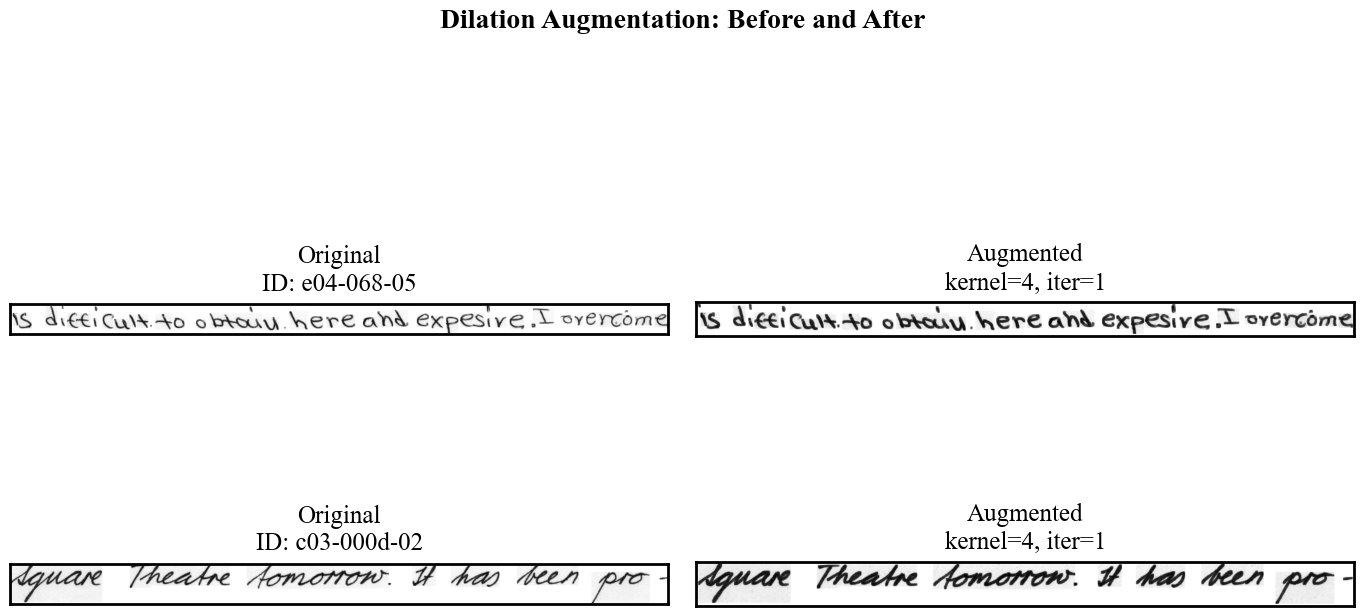

In [190]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_dilation, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Dilation Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    panels = [
        (axes[i, 0], ex["before"], f"Original\nID: {ex['id']}"),
        (
            axes[i, 1],
            ex["after"],
            f"Augmented\nkernel={ex['kernel_size']}, iter={ex['iterations']}"
        )
    ]

    for ax, img, title in panels:
        ax.imshow(img, cmap="gray")
        ax.set_title(title, fontsize=TITLE_SIZE, fontname=FONT_FAMILY, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("dilation.png", dpi = 300)
plt.show()

In [214]:
# pick images for scale and resize
available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

scale_sample = available_df.sample(n=n_images, random_state=49).copy()

print("Selected for scale/resize:", len(scale_sample))
scale_sample.head()

Total images: 13353
Already used: 700
Available: 12653
Selected for scale/resize: 100


,id,sentence,image_path
3616,c04-044-02,"had style, moved at a quick pace and everyone did",lines flattened\c04-044-02.png
2702,b06-059-04,posed so as to cause doubt and confusion,lines flattened\b06-059-04.png
6865,g06-011c-04,resource. Vesuvius seems to be tired ; he is g...,lines flattened\g06-011c-04.png
1521,a05-084-00,The Russians now realised its seriousness. The,lines flattened\a05-084-00.png
13003,r03-026-02,started several decades before had caught on,lines flattened\r03-026-02.png


In [216]:
def scale_text_only_crop_canvas(
    image,
    scale_factor=1.10,
    padding=10,
    outer_padding=6
):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    crop_h, crop_w = text_crop.shape

    new_w = max(1, int(crop_w * scale_factor))
    new_h = max(1, int(crop_h * scale_factor))

    if scale_factor < 1:
        interpolation = cv2.INTER_AREA
    else:
        interpolation = cv2.INTER_CUBIC

    scaled_crop = cv2.resize(
        text_crop,
        (new_w, new_h),
        interpolation=interpolation
    )

    output_h = new_h + 2 * outer_padding
    output_w = new_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + new_h,
        outer_padding:outer_padding + new_w
    ] = scaled_crop

    return output

In [218]:
before_after_scale = []

np.random.seed(49)

for _, row in scale_sample.iterrows():
    original_image = read_image(row["image_path"])

    scale_factor = np.random.uniform(1.5, 1.9)

    scaled_image = scale_text_only_crop_canvas(
        image=original_image,
        scale_factor=scale_factor,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=scaled_image,
        augmentation_name="scale_resize"
    )

    before_after_scale.append({
        "id": row["id"],
        "scale_factor": scale_factor,
        "before": original_image,
        "after": scaled_image
    })

used_ids.update(scale_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Scale/resize augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Scale/resize augmentation done.
Current df_aug shape: (14153, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
dilation            100
scale_resize        100
Name: count, dtype: int64

Used IDs: 800


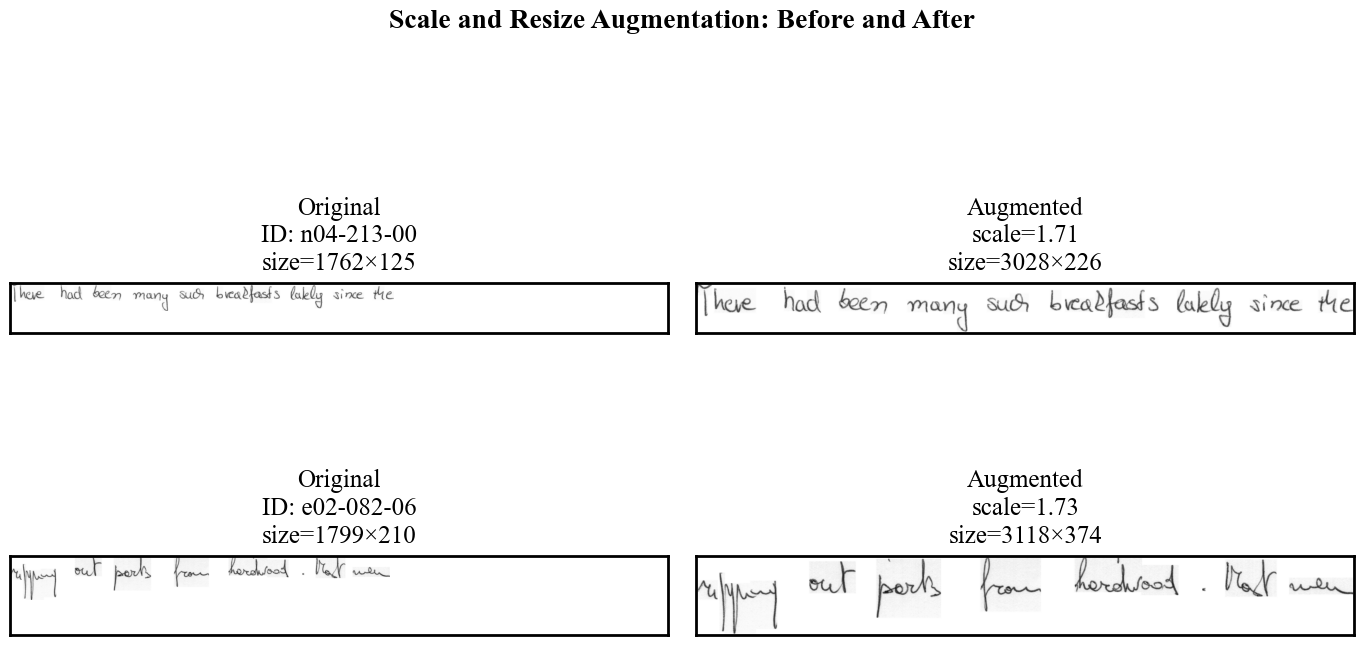

In [228]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_scale, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Scale and Resize Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    before = ex["before"]
    after = ex["after"]

    max_h = max(before.shape[0], after.shape[0])
    max_w = max(before.shape[1], after.shape[1])

    panels = [
        (
            axes[i, 0],
            before,
            f"Original\nID: {ex['id']}\nsize={before.shape[1]}×{before.shape[0]}"
        ),
        (
            axes[i, 1],
            after,
            f"Augmented\nscale={ex['scale_factor']:.2f}\nsize={after.shape[1]}×{after.shape[0]}"
        )
    ]

    for ax, img, title in panels:
        h, w = img.shape

        ax.imshow(
            img,
            cmap="gray",
            vmin=0,
            vmax=255,
            extent=[0, w, h, 0]
        )

        ax.set_xlim(0, max_w)
        ax.set_ylim(max_h, 0)
        ax.set_aspect("equal")

        ax.set_title(
            title,
            fontsize=TITLE_SIZE,
            fontname=FONT_FAMILY,
            pad=10
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("resize.png", dpi = 300)
plt.show()

In [224]:
for ex in before_after_scale[:10]:
    print(
        ex["id"],
        "| before:", ex["before"].shape,
        "| after:", ex["after"].shape,
        "| scale:", round(ex["scale_factor"], 2)
    )

c04-044-02 | before: (262, 2078) | after: (436, 3379) | scale: 1.62
b06-059-04 | before: (122, 1761) | after: (207, 2827) | scale: 1.6
g06-011c-04 | before: (113, 1713) | after: (223, 3216) | scale: 1.87
a05-084-00 | before: (73, 1915) | after: (147, 3567) | scale: 1.86
r03-026-02 | before: (129, 1749) | after: (240, 3113) | scale: 1.77
e02-082-06 | before: (210, 1799) | after: (374, 3118) | scale: 1.73
r03-096-05 | before: (112, 1635) | after: (204, 2822) | scale: 1.72
p03-103-02 | before: (93, 1728) | after: (159, 2749) | scale: 1.58
a04-103-06 | before: (150, 1838) | after: (283, 3334) | scale: 1.81
a05-022-08 | before: (63, 671) | after: (129, 1259) | scale: 1.86


In [230]:
#images for sharpening

available_df = df[~df["id"].isin(used_ids)].copy()

print("Total images:", len(df))
print("Already used:", len(used_ids))
print("Available:", len(available_df))

n_images = 100

if len(available_df) < n_images:
    raise ValueError(f"Only {len(available_df)} unused images remain.")

sharpen_sample = available_df.sample(n=n_images, random_state=50).copy()

print("Selected for sharpening:", len(sharpen_sample))
sharpen_sample.head()

Total images: 13353
Already used: 800
Available: 12553
Selected for sharpening: 100


,id,sentence,image_path
10958,m02-055-08,(literally) all-powerful Rocket Release,lines flattened\m02-055-08.png
7878,g06-047m-00,"This remarkable man of medicine, whom Sir",lines flattened\g06-047m-00.png
9743,k03-144-06,"Hadley, Prebble, Lambert-Price - the",lines flattened\k03-144-06.png
5871,f04-074-05,had walked deliberately into the blackness and,lines flattened\f04-074-05.png
873,a02-111-10,"Committee of 100, the anti-nuclear arms",lines flattened\a02-111-10.png


In [232]:
# sharpen text fucntion

def sharpen_text_only_crop_canvas(
    image,
    sigma=2.0,
    amount=3.0,
    padding=10,
    outer_padding=6
):
    h, w = image.shape

    mask = image < 245
    coords = cv2.findNonZero(mask.astype(np.uint8))

    if coords is None:
        return image.copy()

    x, y, bw, bh = cv2.boundingRect(coords)

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + bw + padding, w)
    y2 = min(y + bh + padding, h)

    text_crop = image[y1:y2, x1:x2]

    blurred = cv2.GaussianBlur(text_crop, (0, 0), sigmaX=sigma)

    sharpened = cv2.addWeighted(
        text_crop, 1 + amount,
        blurred, -amount,
        0
    )

    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    crop_h, crop_w = sharpened.shape

    output_h = crop_h + 2 * outer_padding
    output_w = crop_w + 2 * outer_padding

    output = np.full((output_h, output_w), 255, dtype=np.uint8)

    output[
        outer_padding:outer_padding + crop_h,
        outer_padding:outer_padding + crop_w
    ] = sharpened

    return output

In [234]:
before_after_sharpen = []

np.random.seed(50)

for _, row in sharpen_sample.iterrows():
    original_image = read_image(row["image_path"])

    sigma = np.random.uniform(1.8, 3.0)
    amount = np.random.uniform(3.0, 5.0)

    sharpened_image = sharpen_text_only_crop_canvas(
        image=original_image,
        sigma=sigma,
        amount=amount,
        padding=10,
        outer_padding=6
    )

    df_aug = add_augmented_image(
        df_aug=df_aug,
        original_row=row,
        augmented_image=sharpened_image,
        augmentation_name="sharpen"
    )

    before_after_sharpen.append({
        "id": row["id"],
        "sigma": sigma,
        "amount": amount,
        "before": original_image,
        "after": sharpened_image
    })

used_ids.update(sharpen_sample["id"].tolist())

df_aug.to_csv(AUG_CSV_FILE, index=False)

print("Sharpening augmentation done.")
print("Current df_aug shape:", df_aug.shape)

print("\nAugmentation counts:")
print(df_aug["augmentation"].value_counts())

print("\nUsed IDs:", len(used_ids))

Sharpening augmentation done.
Current df_aug shape: (14253, 4)

Augmentation counts:
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
dilation            100
scale_resize        100
sharpen             100
Name: count, dtype: int64

Used IDs: 900


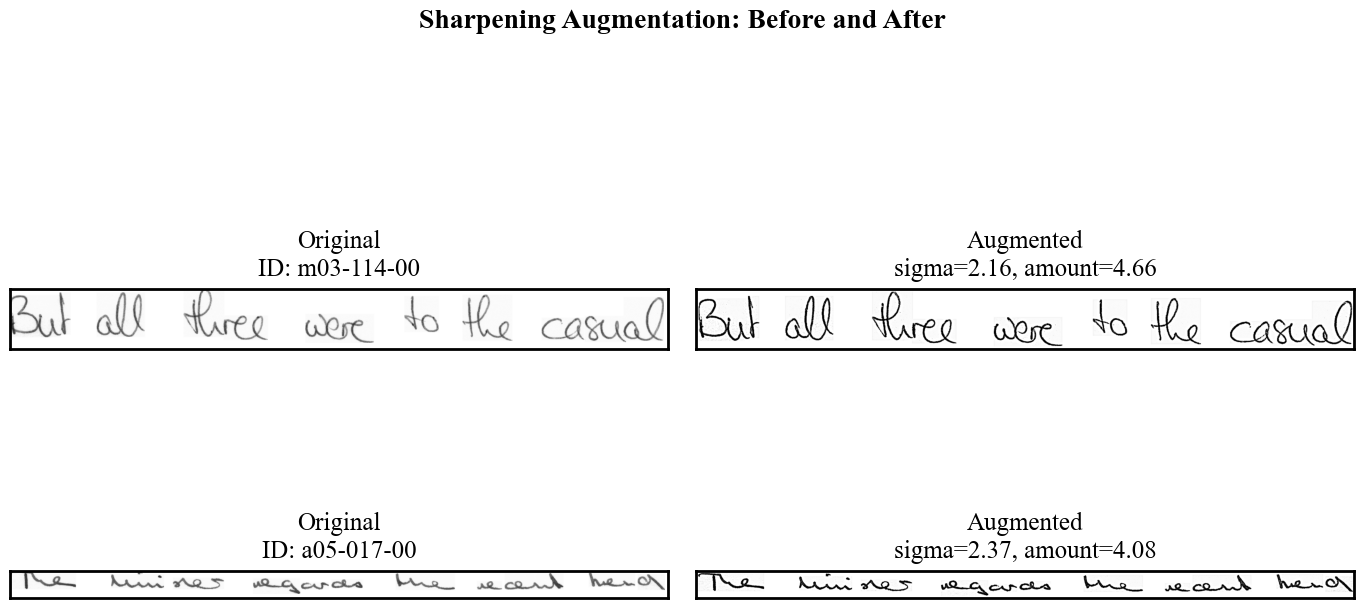

In [264]:
TITLE_SIZE = 18
SUPTITLE_SIZE = 20
FONT_FAMILY = "Times New Roman"

examples = random.sample(before_after_sharpen, 2)

plt.rcParams["font.family"] = FONT_FAMILY

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Sharpening Augmentation: Before and After",
    fontsize=SUPTITLE_SIZE,
    fontname=FONT_FAMILY,
    fontweight="bold",
    y=1.02
)

for i, ex in enumerate(examples):
    before = ex["before"]
    after = ex["after"]

    max_h = max(before.shape[0], after.shape[0])
    max_w = max(before.shape[1], after.shape[1])

    panels = [
        (
            axes[i, 0],
            before,
            f"Original\nID: {ex['id']}"
        ),
        (
            axes[i, 1],
            after,
            f"Augmented\nsigma={ex['sigma']:.2f}, amount={ex['amount']:.2f}"
        )
    ]

    for ax, img, title in panels:
        h, w = img.shape

        ax.imshow(
            img,
            cmap="gray",
            vmin=0,
            vmax=255,
            extent=[0, w, h, 0]
        )

        ax.set_xlim(0, max_w)
        ax.set_ylim(max_h, 0)
        ax.set_aspect("equal")

        ax.set_title(
            title,
            fontsize=TITLE_SIZE,
            fontname=FONT_FAMILY,
            pad=10
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor("black")

plt.tight_layout(pad=2.0)
plt.savefig("sharpen.png", dpi = 300)
plt.show()